# 05 - Task 3: Hyperparameter tuning (xgboost)

Two-stage search (coarse random -> refined grid around the winner) on the model(s)
carried from 04_models.ipynb. Don't over-engineer to chase the public LB.

Trials are cached under `data/processed/tuning_trials/` as soon as they're
scored, tagged with an OWNER. This makes an interrupted run resumable (a rerun skips
whatever's already on disk) and lets teammates split a model's hyperparameter space into
sub-ranges, search them in parallel, and merge automatically. Everyone's trial files
just need to be present (e.g. after a git pull) for the next stage to see them all.

## 0. Setup

Imports, src helpers, paths.

In [7]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import ParameterSampler, ParameterGrid
from xgboost import XGBClassifier

from src import paths, data, evaluation, tuning
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features + the locked split

In [8]:
X, y, ids = data.load_train_features()
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')
cv = evaluation.make_cv()

X_dev, y_dev = X[dev_idx], y[dev_idx]

In [10]:
# Edit this before running your own portion of the search - it tags every trial file
# you produce, so your results are distinguishable from teammates' and nothing gets
#  overwritten when files are merged (e.g. via git pull).
OWNER = "koko_xgboost"  # e.g. "alice_lr_lo" for a named sub-range, see section 2
SEARCH_SEED = 73

## 2. Search space - what each knob does and why this range

Tuning XGB, the second top model from 04_models.ipynb (F1 0.7289). Fixed from that baseline:
- `tree_method="hist"`: fast histogram-based tree building, suitable for this large
  TF-IDF matrix.
- `eval_metric="logloss"`: training metric used internally by XGBoost.
- `scale_pos_weight=n_neg / n_pos`: reduces the influence of the majority
  machine-generated class during training.
- `random_state=42`: makes results reproducible.
- `n_jobs=-1`: uses all available CPU cores.

knobs searched:

- `learning_rate` (log-uniform, 0.01–0.15): how strongly each new tree changes
  the model. Small values learn more cautiously but need more trees.
- `n_estimators` (200–700): number of trees. It works together with
  `learning_rate`; low learning rates normally need more trees.
- `max_depth` (3–8): maximum tree depth. Higher depth can learn more complicated
  combinations of TF-IDF features, but may overfit.
- `min_child_weight` (0.5–20): how much training evidence a branch needs before
  XGBoost creates it. Larger values make the model more conservative.
- `subsample` (0.60–1.00): fraction of training rows used per tree. This adds
  randomness and can reduce overfitting.
- `colsample_bytree` (0.30–0.90): fraction of the 5,000 TF-IDF features available
  to each tree. This is useful because text features are high-dimensional.
- `gamma` (0–2): minimum improvement required before XGBoost makes a split.
  Higher values make trees simpler.
- `reg_alpha` and `reg_lambda`: L1 and L2 regularisation penalties that discourage
  overly complex trees.

Stage 1 samples several combinations broadly. Stage 2 will search more closely
around the best Stage-1 configuration.

## 3. Stage 1 - coarse search

Draws random combinations from the distributions above and scores each one via
`tuning.run_trial`, which writes a cached result file per trial and skips anything
already on disk - safe to interrupt and rerun, and safe to run in parallel with
teammates covering other sub-ranges.

In [11]:
n_pos = int((y_dev == 1).sum())  # machine-generated, class 1
n_neg = int((y_dev == 0).sum())  # human-authored, class 0

param_dist = {
    "learning_rate": loguniform(0.01, 0.15),
    "n_estimators": randint(200, 700),
    "max_depth": randint(3, 9),
    "min_child_weight": loguniform(0.5, 20),
    "subsample": uniform(0.6, 0.4),         # range: 0.60 to 1.00
    "colsample_bytree": uniform(0.3, 0.6),  # range: 0.30 to 0.90
    "gamma": uniform(0.0, 2.0),
    "reg_alpha": loguniform(1e-4, 2.0),
    "reg_lambda": loguniform(0.1, 10.0),
}

N_ITER = 12 #12 different hyperparam
sampler = ParameterSampler(
    param_dist,
    n_iter=N_ITER,
    random_state=SEARCH_SEED,
)

for i, params in enumerate(sampler, start=1):
    print(f"[{i}/{N_ITER}] {params}")

    est = XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        scale_pos_weight=n_neg / n_pos,
        random_state=42,
        n_jobs=-1,
        **params,
    )

    result = tuning.run_trial(
        "xgboost_stage1",
        OWNER,
        est,
        params,
        X_dev,
        y_dev,
        cv,
    )

    print(f"  mean={result['mean']:.4f}  std={result['std']:.4f}")

[1/12] {'colsample_bytree': np.float64(0.6856139494716473), 'gamma': np.float64(1.0772418619378938), 'learning_rate': np.float64(0.03999804297671656), 'max_depth': 6, 'min_child_weight': np.float64(3.387947642793), 'n_estimators': 562, 'reg_alpha': np.float64(0.0008363874073008293), 'reg_lambda': np.float64(0.30758137820025666), 'subsample': np.float64(0.828837810391359)}
  mean=0.7258  std=0.0040
[2/12] {'colsample_bytree': np.float64(0.7635771982350354), 'gamma': np.float64(0.6212559037962915), 'learning_rate': np.float64(0.029870238436489106), 'max_depth': 6, 'min_child_weight': np.float64(3.0621263861923906), 'n_estimators': 572, 'reg_alpha': np.float64(0.7861912494413225), 'reg_lambda': np.float64(0.2081726496562996), 'subsample': np.float64(0.8354654702718157)}
  mean=0.7205  std=0.0073
[3/12] {'colsample_bytree': np.float64(0.4571829398464734), 'gamma': np.float64(1.7526794407406039), 'learning_rate': np.float64(0.12048044987380184), 'max_depth': 7, 'min_child_weight': np.float6

## 4. Merge stage-1 results across teammates

Pulls in every stage-1 trial file present on disk - all owners, all sub-ranges. This is
the merge step: as long as everyone's trial files are in
`data/processed/tuning_trials/` (e.g. after a `git pull`), no manual CSV-concatenation
is needed.

In [ ]:
stage1_trials = tuning.load_trials("xgboost_stage1")

print(
    f"{len(stage1_trials)} XGBoost Stage-1 trials merged, "
    f"from owners: {sorted(stage1_trials['owner'].unique())}"
)

print(
    stage1_trials[
        ["owner", "params", "mean", "std"]
    ].to_string()
)

center = stage1_trials.iloc[0]["params"]

print("\nBest Stage-1 configuration:")
print(center)

12 XGBoost Stage-1 trials merged, from owners: ['koko_xgboost']
           owner                                                                                                                                                                                                                                                                                            params      mean       std
0   koko_xgboost      {'colsample_bytree': 0.3162868269283168, 'gamma': 0.8121138923088622, 'learning_rate': 0.07405598773635837, 'max_depth': 8, 'min_child_weight': 2.09552917526889, 'n_estimators': 421, 'reg_alpha': 0.017594478078571892, 'reg_lambda': 1.3980155864084545, 'subsample': 0.9933800622363407}  0.731376  0.004780
1   koko_xgboost     {'colsample_bytree': 0.7017113238821435, 'gamma': 1.3432207806182836, 'learning_rate': 0.08430830808188122, 'max_depth': 7, 'min_child_weight': 0.5784113635932211, 'n_estimators': 434, 'reg_alpha': 0.3022559108680906, 'reg_lambda': 0.21065752850621194, 'subsamp

## 5. Stage 2 — refined search around the Stage-1 winner

Stage 1 searched broadly across nine XGBoost hyperparameters. Stage 2 now searches
more carefully around the best Stage-1 configuration.

We vary two important settings:

- `learning_rate`: nearby slower and faster learning rates;
- `max_depth`: nearby simpler and more complex trees.

All other hyperparameters remain fixed at the Stage-1 winner's values.

Best Stage-1 configuration:

{'colsample_bytree': 0.3162868269283168, 'gamma': 0.8121138923088622, 'learning_rate': 0.07405598773635837, 'max_depth': 8, 'min_child_weight': 2.09552917526889, 'n_estimators': 421, 'reg_alpha': 0.017594478078571892, 'reg_lambda': 1.3980155864084545, 'subsample': 0.9933800622363407}

This creates a small, focused grid rather than another broad random search.

In [13]:
def rate_band(value):
    return sorted({
        round(max(0.005, value * 0.6), 6),
        round(value, 6),
        round(value * 1.4, 6),
    })


def depth_band(value):
    value = int(value)
    return sorted({
        max(2, value - 2),
        value,
        value + 2,
    })


center = stage1_trials.iloc[0]["params"]

refined_grid = {
    "learning_rate": rate_band(center["learning_rate"]),
    "max_depth": depth_band(center["max_depth"]),
}

fixed_params = {
    key: value
    for key, value in center.items()
    if key not in refined_grid
}

combos = list(ParameterGrid(refined_grid))

print(f"Refined grid: {len(combos)} combinations")
print("Values being changed:", refined_grid)
print("Values held fixed:", fixed_params)

grid_results = []

for i, grid_params in enumerate(combos, start=1):
    params = {**fixed_params, **grid_params}

    print(f"\n[{i}/{len(combos)}] {params}")

    est = XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        scale_pos_weight=n_neg / n_pos,
        random_state=42,
        n_jobs=-1,
        **params,
    )

    result = tuning.run_trial(
        "xgboost_stage2",
        OWNER,
        est,
        params,
        X_dev,
        y_dev,
        cv,
    )

    print(
        f"mean={result['mean']:.4f} "
        f"std={result['std']:.4f}"
    )

    grid_results.append({
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "mean": result["mean"],
        "std": result["std"],
    })

Refined grid: 9 combinations
Values being changed: {'learning_rate': [0.044434, 0.074056, 0.103678], 'max_depth': [6, 8, 10]}
Values held fixed: {'colsample_bytree': 0.3162868269283168, 'gamma': 0.8121138923088622, 'min_child_weight': 2.09552917526889, 'n_estimators': 421, 'reg_alpha': 0.017594478078571892, 'reg_lambda': 1.3980155864084545, 'subsample': 0.9933800622363407}

[1/9] {'colsample_bytree': 0.3162868269283168, 'gamma': 0.8121138923088622, 'min_child_weight': 2.09552917526889, 'n_estimators': 421, 'reg_alpha': 0.017594478078571892, 'reg_lambda': 1.3980155864084545, 'subsample': 0.9933800622363407, 'learning_rate': 0.044434, 'max_depth': 6}
mean=0.7178 std=0.0087

[2/9] {'colsample_bytree': 0.3162868269283168, 'gamma': 0.8121138923088622, 'min_child_weight': 2.09552917526889, 'n_estimators': 421, 'reg_alpha': 0.017594478078571892, 'reg_lambda': 1.3980155864084545, 'subsample': 0.9933800622363407, 'learning_rate': 0.044434, 'max_depth': 8}
mean=0.7273 std=0.0049

[3/9] {'colsamp

### Visualize the grid search

Heatmap of Macro F1 across the refined `learning_rate` x `num_leaves` grid (the two
knobs actually varied in stage 2), with every other hyperparameter held fixed at the
stage-1 winner's value.

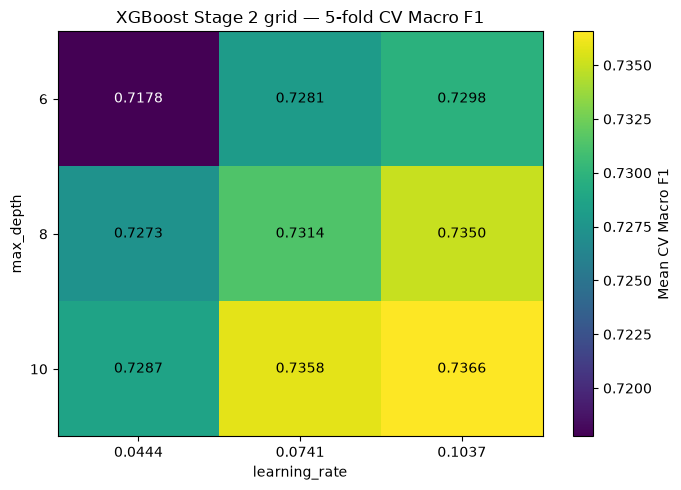

In [14]:
grid_df = pd.DataFrame(grid_results)

pivot = (
    grid_df
    .pivot(index="max_depth", columns="learning_rate", values="mean")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:.4f}" for c in pivot.columns])

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("learning_rate")
ax.set_ylabel("max_depth")
ax.set_title("XGBoost Stage 2 grid — 5-fold CV Macro F1")

vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)
mid = (vmin + vmax) / 2

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        value = pivot.values[i, j]
        ax.text(
            j, i, f"{value:.4f}",
            ha="center",
            va="center",
            color="white" if value < mid else "black",
        )

fig.colorbar(im, ax=ax, label="Mean CV Macro F1")

plt.tight_layout()
plt.savefig(FIGURES / "xgboost_stage2_grid_heatmap.png", dpi=120)
plt.show()

Only the winning XGBoost configuration is refit and saved locally here. The fitted
XGBoost model is machine-specific and gitignored; teammates merge the small trial JSON
files instead.

In [15]:
stage2_trials = tuning.load_trials("xgboost_stage2")

all_trials = (
    pd.concat([stage1_trials, stage2_trials], ignore_index=True)
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
)

overall_best = all_trials.iloc[0]
best_params = overall_best["params"]

print(
    f"Best trial across Stage 1 ({len(stage1_trials)}) "
    f"+ Stage 2 ({len(stage2_trials)}) "
    f"= {len(all_trials)} total trials"
)

print("\nWinning XGBoost hyperparameters:")
print(best_params)

print(
    f"\nWinning 5-fold CV Macro F1: {overall_best['mean']:.4f} "
    f"(std {overall_best['std']:.4f})"
)

paths.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

with open(paths.DATA_PROCESSED / "best_xgboost_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

final_est = XGBClassifier(
    tree_method="hist",
    eval_metric="logloss",
    scale_pos_weight=n_neg / n_pos,
    random_state=42,
    n_jobs=-1,
    **best_params,
)

final_est.fit(X_dev, y_dev)

paths.MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump(final_est, paths.MODELS / "best_xgboost_tuned.pkl")

metadata = {
    "model": "xgboost",
    "params": best_params,
    "cv_mean_f1": overall_best["mean"],
    "cv_std_f1": overall_best["std"],
    "n_stage1_trials": len(stage1_trials),
    "n_stage2_trials": len(stage2_trials),
}

with open(paths.MODELS / "best_xgboost_tuned.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(
    "\nSaved:\n"
    "- data/processed/best_xgboost_params.json\n"
    "- models/best_xgboost_tuned.pkl\n"
    "- models/best_xgboost_tuned.json"
)

Best trial across Stage 1 (12) + Stage 2 (9) = 21 total trials

Winning XGBoost hyperparameters:
{'colsample_bytree': 0.3162868269283168, 'gamma': 0.8121138923088622, 'min_child_weight': 2.09552917526889, 'n_estimators': 421, 'reg_alpha': 0.017594478078571892, 'reg_lambda': 1.3980155864084545, 'subsample': 0.9933800622363407, 'learning_rate': 0.103678, 'max_depth': 10}

Winning 5-fold CV Macro F1: 0.7366 (std 0.0056)

Saved:
- data/processed/best_xgboost_params.json
- models/best_xgboost_tuned.pkl
- models/best_xgboost_tuned.json


## Discussion / carry-forward

### XGBoost tuning result

XGBoost's baseline result in `04_models.ipynb` was **0.7289 Macro F1**
under the locked 5-fold stratified CV protocol.

This notebook ran:

- Stage 1: 12 broad random-search trials;
- Stage 2: 9 refined grid-search trials around the Stage-1 winner;
- Total: 21 XGBoost configurations.

### Winning hyperparameters

```text
learning_rate:     0.103678
max_depth:         10
n_estimators:      421
min_child_weight:  2.095529
subsample:         0.993380
colsample_bytree:  0.316287
gamma:             0.812114
reg_alpha:         0.017594
reg_lambda:        1.398016